In [ ]:
#!pip install wandb==0.13.10 protobuf==3.20.3
!pip install -q segmentation-models-pytorch
!pip install -q torchsummary
!pip install -q rasterio
!pip install -q colorama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
import logging
import warnings

warnings.filterwarnings("ignore", module="tifffile")
logging.getLogger("tifffile").disabled = True

In [ ]:
# Misc
import os
import copy
import time
import timm
import joblib
import random
import tifffile
import os, shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from IPython import display as ipd
from collections import defaultdict
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, KFold

# Pytorch
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.cuda import amp
from torch.autograd import Variable
from torch.optim import lr_scheduler
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

from torchsummary import summary
import segmentation_models_pytorch as smp

# Image Processing Libraries
import cv2
import rasterio
import skimage.io
import io

from PIL import Image

# Albumentations for augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# For colored terminal text
from colorama import Fore, Back, Style
c_  = Fore.GREEN
sr_ = Style.RESET_ALL

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import warnings
warnings.filterwarnings("ignore")

# For descriptive error messages
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

import gc
gc.collect()

60

In [ ]:
class CFG:
    seed          = 101
    debug         = False # set debug=False for Full Training
    exp_name      = 'Baselinev1'
    comment       = 'Linknet-Efficientnet-b7-512x512-aug2-split2'
    model_name    = 'Linknet'
    encoder       = 'efficientnet-b7'
    train_bs      = 16
    valid_bs      = train_bs
    img_size      = [512, 512]
    size          = 512
    epochs        = 50
    lr            = 1e-3
    scheduler     = 'CosineAnnealingLR'
    min_lr        = 1e-6
    T_max         = int(10000/train_bs*epochs)+50
    T_0           = 25
    warmup_epochs = 0
    wd            = 1e-4
    n_fold        = 5
    num_classes   = 2
    device        = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
def set_seed(seed = 42):
    '''Sets the seed of the entire notebook so results are the same every time we run.
    This is for REPRODUCIBILITY.'''
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    print('> SEEDING DONE')

set_seed(CFG.seed)

> SEEDING DONE


In [ ]:
# Image and Mask Path
IMAGE_PATH = '/content/drive/MyDrive/BlueCARES_Seagrass/dataset/training_images/'
MASK_PATH = '/content/drive/MyDrive/BlueCARES_Seagrass/dataset/training_label/'

n_classes = 2

def create_df():
    img_name = []
    for dirname, _, filenames in os.walk(IMAGE_PATH):
        for filename in filenames:
            img_name.append(filename.split('.')[0])

    mask_name = []
    for dirname, _, filenames in os.walk(MASK_PATH):
        for filename in filenames:
            mask_name.append(filename.split('.')[0])

    img_name = sorted(img_name)
    mask_name = sorted(mask_name)

    return pd.DataFrame({'img_id': img_name, 'mask_id': mask_name}, index = np.arange(0, len(img_name)))

df = create_df()
print('Total Images: ', len(df))

df # list of drone images

Total Images:  1130


,img_id,mask_id
0,1B102321_01_01,1B102321_01_01
1,1B102321_01_02,1B102321_01_02
2,1B102321_01_03,1B102321_01_03
3,1B102321_01_04,1B102321_01_04
4,1B102321_01_05,1B102321_01_05
...,...,...
1125,tile_r1_c1_13_09,tile_r1_c1_13_09
1126,tile_r1_c1_13_10,tile_r1_c1_13_10
1127,tile_r1_c1_13_11,tile_r1_c1_13_11
1128,tile_r1_c1_13_12,tile_r1_c1_13_12


In [ ]:
# Split data
X_trainval, X_test = train_test_split(df['img_id'].values, test_size=0.1, random_state=19)
X_train, X_val = train_test_split(X_trainval, test_size=0.15, random_state=19)

print('Train Size   : ', len(X_train))
print('Val Size     : ', len(X_val))
print('Test Size    : ', len(X_test))

Train Size   :  864
Val Size     :  153
Test Size    :  113


Image Size (512, 512, 3)
Mask Size (512, 512)


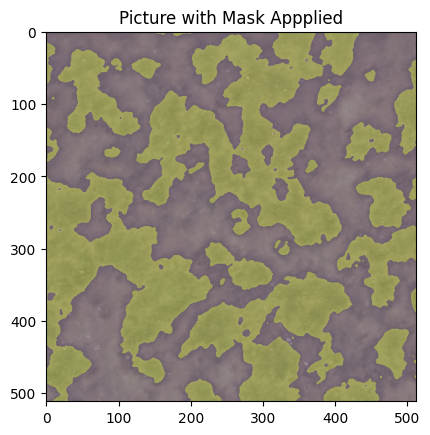

In [ ]:
img = skimage.io.imread(IMAGE_PATH + df['img_id'][500] + '.tif', plugin='tifffile')
mask = skimage.io.imread(MASK_PATH + df['mask_id'][500] + '.tif', plugin='tifffile')
print('Image Size', np.asarray(img).shape)
print('Mask Size', np.asarray(mask).shape)


plt.imshow(img)
plt.imshow(mask, alpha=0.30)
plt.title('Picture with Mask Appplied')
plt.show()

In [ ]:
class DroneDataset(Dataset):

    def __init__(self, img_path, mask_path, X, transform=None, patch=False):
        self.img_path = img_path
        self.mask_path = mask_path
        self.X = X
        self.patches = patch
        self.transform = transform

        # Your custom mean/std
        self.mean = [0.4855, 0.5464, 0.4754]
        self.std = [0.1446, 0.1593, 0.1308]

        # Define transforms
        if self.transform is None:
            self.base_transform = A.Compose([
                A.Resize(CFG.size, CFG.size),
                A.Normalize(mean=self.mean, std=self.std),
                ToTensorV2()
            ])
        else:
            self.base_transform = A.Compose([
                A.Resize(CFG.size, CFG.size),
                self.transform,
                A.Normalize(mean=self.mean, std=self.std),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Construct file paths
        img_file = f"{self.img_path}{self.X[idx]}.tif"
        mask_file = f"{self.mask_path}{self.X[idx]}.tif"

        # ===== FIXED: Use tifffile for reliable TIFF loading =====
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                # Load image with tifffile (handles all TIFF types)
                img = tifffile.imread(img_file)

                # Load mask
                mask = tifffile.imread(mask_file)

        except Exception as e:
            # Fallback to PIL if tifffile fails
            from PIL import Image
            img = np.array(Image.open(img_file))
            mask = np.array(Image.open(mask_file))
            #print(f"Warning: Used PIL fallback for {self.X[idx]}: {e}")

        # ===== FIXED: Convert image to proper format =====
        # Check image properties
        # print(f"Debug - Image {self.X[idx]}: shape={img.shape}, dtype={img.dtype}, min={img.min()}, max={img.max()}")

        # Convert to appropriate format based on dtype
        if img.dtype == np.int32 or img.dtype == np.uint32:
            # 32-bit integer: scale to 0-255 or normalize
            img = img.astype(np.float32)

            # Option 1: Scale to 0-255 (for display/normalization)
            if img.max() > 1.0:  # Likely not normalized
                img_min, img_max = img.min(), img.max()
                if img_max > img_min:
                    img = (img - img_min) / (img_max - img_min) * 255.0

            # Convert to uint8 for OpenCV/albumentations
            img = img.astype(np.uint8)

        elif img.dtype == np.float64:
            # 64-bit float: convert to 32-bit float
            img = img.astype(np.float32)

        # Ensure 3 channels for RGB
        if img.ndim == 2:
            # Single channel: convert to 3-channel
            img = np.stack([img, img, img], axis=2)
        elif img.ndim == 3 and img.shape[2] == 1:
            # Single channel with dimension: (H, W, 1)
            img = np.repeat(img, 3, axis=2)
        elif img.ndim == 3 and img.shape[2] == 4:
            # RGBA: drop alpha channel
            img = img[:, :, :3]

        # ===== FIXED: Process mask =====
        # Mask should be single channel for segmentation
        if mask.ndim == 3:
            # Take first channel or convert to grayscale
            if mask.shape[2] == 3:
                # Convert RGB mask to single channel (example: take mean)
                mask = mask.mean(axis=2).astype(np.uint8)
            else:
                mask = mask[:, :, 0]

        # Ensure mask is uint8 for albumentations
        if mask.dtype != np.uint8:
            mask = mask.astype(np.uint8)

        # ===== Apply transforms =====
        if self.transform is not None:
            augmented = self.base_transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        else:
            augmented = self.base_transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # Convert mask to Long tensor for segmentation
        mask = mask.long()

        # Apply patching if needed
        if self.patches:
            img, mask = self.tiles(img, mask)

        return img, mask

    def tiles(self, img, mask):
        """Extract patches from image and mask"""
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)

        img_patches = img.unfold(1, CFG.size, CFG.size).unfold(2, CFG.size, CFG.size)
        img_patches = img_patches.contiguous().view(img.shape[0], -1, CFG.size, CFG.size)
        img_patches = img_patches.permute(1, 0, 2, 3)

        mask_patches = mask.unfold(1, CFG.size, CFG.size).unfold(2, CFG.size, CFG.size)
        mask_patches = mask_patches.contiguous().view(mask.shape[0], -1, CFG.size, CFG.size)
        mask_patches = mask_patches.permute(1, 0, 2, 3)

        if mask_patches.shape[1] == 1:
            mask_patches = mask_patches.squeeze(1)

        return img_patches, mask_patches

In [ ]:
# Data Augmentation
t_train = A.Compose([A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
                     A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.05, rotate_limit=10, p=0.5),
                     A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.25, p=0.75),
                     A.GridDistortion(num_steps=5, distort_limit=0.3, interpolation=1, p=0.5),
                     A.RandomBrightnessContrast((0,0.5),(0,0.5)),
                     A.GaussNoise()])

t_val = A.Compose([A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
                   A.GridDistortion(num_steps=5, distort_limit=0.3, interpolation=1, p=0.5)])

#datasets

train_set = DroneDataset(IMAGE_PATH, MASK_PATH, X_train, t_train, patch=False)
train_loader = DataLoader(train_set, batch_size=CFG.train_bs, shuffle=True, num_workers=0, pin_memory=True)

val_set = DroneDataset(IMAGE_PATH, MASK_PATH, X_val, t_val, patch=False)
val_loader = DataLoader(val_set, batch_size=CFG.valid_bs, shuffle=True, num_workers=0, pin_memory=True)

imgs, msks = next(iter(train_loader))
imgs.size(), msks.size()

(torch.Size([16, 3, 512, 512]), torch.Size([16, 512, 512]))

In [ ]:
def build_model():

    if CFG.model_name == 'UNet':

        model = smp.Unet(
            encoder_name = CFG.encoder,
            encoder_weights = 'imagenet',
            encoder_depth = 5,
            classes = CFG.num_classes,
            activation = 'sigmoid',
            decoder_channels = [256, 128, 64, 32, 16]
        )

    elif CFG.model_name == 'UNetPlusPlus':

        model = smp.UnetPlusPlus(
            encoder_name = CFG.encoder,
            encoder_weights = 'imagenet',
            encoder_depth = 5,
            classes = CFG.num_classes,
            activation = 'sigmoid',
            decoder_channels = [256, 128, 64, 32, 16]
        )

    elif CFG.model_name == 'Linknet':

        model = smp.Linknet(
            encoder_name = CFG.encoder,
            encoder_weights = 'imagenet',
            encoder_depth = 5,
            classes = CFG.num_classes,
            activation = 'sigmoid',
            decoder_use_batchnorm = True
        )

    elif CFG.model_name == 'FPN':

        model = smp.FPN(
            encoder_name = CFG.encoder,
            encoder_weights = 'imagenet',
            encoder_depth = 5,
            classes = CFG.num_classes,
            activation = 'sigmoid',
            decoder_pyramid_channels = 256
        )

    elif CFG.model_name == 'DeepLabV3':

        model = smp.DeepLabV3(
            encoder_name = CFG.encoder,
            encoder_weights = 'imagenet',
            encoder_depth = 5,
            classes = CFG.num_classes,
            activation = 'sigmoid',
            decoder_channels = 256
        )

    model.to(CFG.device)
    return model

def load_model(path):

    model = build_model()
    model.load_state_dict(torch.load(path))
    model.eval()
    return model

In [ ]:
# Loss Function
CrossEntropyLoss = nn.CrossEntropyLoss()
BCELoss = nn.BCELoss()

# Metrics
def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy

def dice_coef(pred_mask, mask, smooth = 1):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        mask = torch.flatten(mask).to(torch.float32)
        pred_mask = torch.flatten(pred_mask).to(torch.float32)

        intersection = torch.sum(mask * pred_mask)
        score = (2. * intersection + smooth) / (torch.sum(mask) + torch.sum(pred_mask) + smooth)

    return score.cpu().numpy()

def mIoU(pred_mask, mask, smooth=1e-10, n_classes=23):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)

    return np.nanmean(iou_per_class)

In [ ]:
def train_one_epoch(model, optimizer, scheduler, criterion, dataloader, device, epoch, patch=False):

    model.train()

    scaler = amp.GradScaler()

    dataset_size = 0
    running_loss = 0.0

    train_scores = []

    pbar = tqdm(enumerate(dataloader), total = len(dataloader), desc = 'Train')
    for steps, (images, masks) in pbar:

        images = images.to(device)
        masks = masks.to(device)

        batch_size = images.size(0)

        y_pred = model(images)
        loss = criterion(y_pred, masks)

        loss.backward()

        # Zero the parameter gradients
        optimizer.step()
        optimizer.zero_grad()

        scheduler.step()

        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size

        epoch_loss = running_loss / dataset_size

        train_iou = mIoU(y_pred, masks)
        train_acc = pixel_accuracy(y_pred, masks)
        train_dce = dice_coef(y_pred, masks)
        train_scores.append([train_iou, train_acc, train_dce])

        mem = torch.cuda.memory_reserved() / 1E9 if torch.cuda.is_available() else 0
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(train_loss = f'{epoch_loss:0.4f}',
                        lr = f'{current_lr:0.5f}',
                        gpu_mem = f'{mem:0.2f} GB')

    train_scores = np.mean(train_scores, axis = 0)

    torch.cuda.empty_cache()
    gc.collect()

    return epoch_loss, train_scores

In [ ]:
@torch.no_grad()
def valid_one_epoch(model, dataloader, criterion, device, epoch):

    model.eval()

    dataset_size = 0
    running_loss = 0.0

    val_scores = []

    pbar = tqdm(enumerate(dataloader), total = len(dataloader), desc = 'Validation')
    for steps, (images, masks) in pbar:

        images = images.to(device)
        masks = masks.to(device)

        batch_size = images.size(0)

        y_pred = model(images)
        loss = criterion(y_pred, masks)

        running_loss += (loss.item() * batch_size)
        dataset_size += batch_size

        epoch_loss = running_loss / dataset_size

        val_iou = mIoU(y_pred, masks)
        val_acc = pixel_accuracy(y_pred, masks)
        val_dce = dice_coef(y_pred, masks)
        val_scores.append([val_iou, val_acc, val_dce])

        mem = torch.cuda.memory_reserved() / 1E9 if torch.cuda.is_available() else 0
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(valid_loss = f'{epoch_loss:0.4f}',
                          lr = f'{current_lr:0.5f}',
                          gpu_memory = f'{mem:0.2f} GB')

    val_scores = np.mean(val_scores, axis=0)
    torch.cuda.empty_cache()
    gc.collect()

    return epoch_loss, val_scores

In [ ]:
def visualize_predictions_during_training(model, dataloader, device, epoch, save_dir, num_samples=4):
    """
    Visualize predictions during training with enhanced layout.
    Shows: Original Image | Ground Truth | Prediction | Error Map
    """
    model.eval()

    # Get a batch
    images, masks = next(iter(dataloader))
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        predictions = model(images)
        pred_masks = torch.argmax(F.softmax(predictions, dim=1), dim=1)

    # Select samples to visualize
    num_samples = min(num_samples, images.size(0))

    fig = plt.figure(figsize=(20, 5*num_samples))
    gs = GridSpec(num_samples, 5, figure=fig, hspace=0.3, wspace=0.3)

    for idx in range(num_samples):
        # Convert tensors to numpy
        img = images[idx].cpu().permute(1, 2, 0).numpy()

        # Denormalize image
        mean = np.array([0.4855, 0.5464, 0.4754])
        std = np.array([0.1446, 0.1593, 0.1308])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        gt_mask = masks[idx].cpu().numpy()
        pred_mask = pred_masks[idx].cpu().numpy()

        # Calculate metrics for this sample
        iou = calculate_sample_iou(pred_mask, gt_mask)
        dice = calculate_sample_dice(pred_mask, gt_mask)
        accuracy = calculate_sample_accuracy(pred_mask, gt_mask)

        # 1. Original Image
        ax1 = fig.add_subplot(gs[idx, 0])
        ax1.imshow(img)
        ax1.set_title(f'Original Image', fontsize=12, fontweight='bold')
        ax1.axis('off')

        # 2. Ground Truth with Stats
        ax2 = fig.add_subplot(gs[idx, 1])
        gt_colored = create_colored_mask(gt_mask)
        ax2.imshow(gt_colored)
        gt_pixels = np.sum(gt_mask > 0)
        ax2.set_title(f'Ground Truth\n({gt_pixels:,} pixels)', fontsize=12, fontweight='bold')
        ax2.axis('off')

        # 3. Prediction with Stats
        ax3 = fig.add_subplot(gs[idx, 2])
        pred_colored = create_colored_mask(pred_mask)
        ax3.imshow(pred_colored)
        pred_pixels = np.sum(pred_mask > 0)
        ax3.set_title(f'Prediction\n({pred_pixels:,} pixels)', fontsize=12, fontweight='bold')
        ax3.axis('off')

        # 4. Error Map (TP, FP, FN)
        ax4 = fig.add_subplot(gs[idx, 3])
        error_map = create_error_map(pred_mask, gt_mask)
        ax4.imshow(error_map)
        ax4.set_title('Error Analysis\nWhite=TP, Red=FP, Blue=FN', fontsize=11, fontweight='bold')
        ax4.axis('off')

        # 5. Metrics Display
        ax5 = fig.add_subplot(gs[idx, 4])
        ax5.axis('off')

        metrics_text = (
            f"METRICS\n"
            f"{'='*30}\n\n"
            f"IoU:       {iou:.4f}\n"
            f"Dice:      {dice:.4f}\n"
            f"Accuracy:  {accuracy:.4f}\n\n"
            f"{'='*30}\n\n"
            f"GT Pixels:   {gt_pixels:,}\n"
            f"Pred Pixels: {pred_pixels:,}\n"
            f"Diff:        {pred_pixels - gt_pixels:+,}\n"
        )

        ax5.text(0.1, 0.5, metrics_text,
                fontsize=11,
                verticalalignment='center',
                family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    plt.suptitle(f'Epoch {epoch} - Prediction Visualization',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig(f'{save_dir}/predictions_epoch_{epoch:03d}.png',
                dpi=150, bbox_inches='tight')
    plt.close()

    model.train()


def create_colored_mask(mask, num_classes=2):
    """Create colored visualization of mask."""
    if num_classes == 2:
        # Binary mask: background (black) and foreground (green)
        colored = np.zeros((*mask.shape, 3))
        colored[mask == 1] = [0, 1, 0]  # Green for class 1
    else:
        # Multi-class: use colormap
        cmap = plt.cm.get_cmap('tab20', num_classes)
        colored = cmap(mask)[:, :, :3]

    return colored


def create_error_map(pred_mask, gt_mask):
    """
    Create error visualization:
    - White: True Positives
    - Red: False Positives
    - Blue: False Negatives
    - Black: True Negatives
    """
    error_map = np.zeros((*pred_mask.shape, 3))

    # True Positives (both predict and actual are positive)
    tp = (pred_mask > 0) & (gt_mask > 0)
    error_map[tp] = [1, 1, 1]  # White

    # False Positives (predict positive, actual negative)
    fp = (pred_mask > 0) & (gt_mask == 0)
    error_map[fp] = [1, 0, 0]  # Red

    # False Negatives (predict negative, actual positive)
    fn = (pred_mask == 0) & (gt_mask > 0)
    error_map[fn] = [0, 0, 1]  # Blue

    # True Negatives remain black

    return error_map


def calculate_sample_iou(pred, gt):
    """Calculate IoU for a single sample."""
    pred = pred > 0
    gt = gt > 0
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / (union + 1e-6)


def calculate_sample_dice(pred, gt):
    """Calculate Dice coefficient for a single sample."""
    pred = pred > 0
    gt = gt > 0
    intersection = np.logical_and(pred, gt).sum()
    return (2 * intersection) / (pred.sum() + gt.sum() + 1e-6)


def calculate_sample_accuracy(pred, gt):
    """Calculate accuracy for a single sample."""
    return (pred == gt).sum() / pred.size


In [ ]:
def plot_comprehensive_metrics(history, save_dir):
    """
    Plot comprehensive training metrics in a professional layout.
    """
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)

    epochs = range(1, len(history['Train Loss']) + 1)

    # 1. Loss Comparison (Large)
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(epochs, history['Train Loss'], 'b-', linewidth=2.5, label='Train Loss', marker='o', markersize=4)
    ax1.plot(epochs, history['Valid Loss'], 'r-', linewidth=2.5, label='Valid Loss', marker='s', markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_facecolor('#f8f9fa')

    # Add best epoch marker
    best_epoch = np.argmin(history['Valid Loss']) + 1
    best_loss = np.min(history['Valid Loss'])
    ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2)
    ax1.plot(best_epoch, best_loss, 'g*', markersize=20, label=f'Best Epoch {best_epoch}')
    ax1.legend(fontsize=11, loc='best')

    # 2. IoU Comparison
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(epochs, history['Train IoU'], 'g-', linewidth=2, label='Train IoU', marker='o', markersize=3)
    ax2.plot(epochs, history['Valid IoU'], 'orange', linewidth=2, label='Valid IoU', marker='s', markersize=3)
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('IoU Score', fontsize=11, fontweight='bold')
    ax2.set_title('IoU Metrics', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f8f9fa')

    # 3. Dice Coefficient
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, history['Train Dice'], 'purple', linewidth=2, label='Train Dice', marker='o', markersize=3)
    ax3.plot(epochs, history['Valid Dice'], 'magenta', linewidth=2, label='Valid Dice', marker='s', markersize=3)
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Dice Score', fontsize=11, fontweight='bold')
    ax3.set_title('Dice Coefficient', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_facecolor('#f8f9fa')

    # 4. Pixel Accuracy
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, history['Train Pixel Accuracy'], 'cyan', linewidth=2, label='Train Accuracy', marker='o', markersize=3)
    ax4.plot(epochs, history['Valid Pixel Accuracy'], 'navy', linewidth=2, label='Valid Accuracy', marker='s', markersize=3)
    ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax4.set_title('Pixel Accuracy', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_facecolor('#f8f9fa')

    # 5. Overfitting Indicator
    ax5 = fig.add_subplot(gs[1, 2])
    train_loss = np.array(history['Train Loss'])
    valid_loss = np.array(history['Valid Loss'])
    overfit_indicator = valid_loss - train_loss

    colors = ['red' if x > 0 else 'green' for x in overfit_indicator]
    ax5.bar(epochs, overfit_indicator, color=colors, alpha=0.7, edgecolor='black')
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Val Loss - Train Loss', fontsize=11, fontweight='bold')
    ax5.set_title('Overfitting Indicator\n(Lower is Better)', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_facecolor('#f8f9fa')

    # 6. All Metrics Comparison (Train)
    ax6 = fig.add_subplot(gs[2, 0])
    ax6.plot(epochs, history['Train IoU'], label='IoU', linewidth=2, marker='o', markersize=3)
    ax6.plot(epochs, history['Train Dice'], label='Dice', linewidth=2, marker='s', markersize=3)
    ax6.plot(epochs, history['Train Pixel Accuracy'], label='Accuracy', linewidth=2, marker='^', markersize=3)
    ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax6.set_title('Training Metrics', fontsize=13, fontweight='bold')
    ax6.legend(fontsize=10)
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim([0, 1])
    ax6.set_facecolor('#f8f9fa')

    # 7. All Metrics Comparison (Valid)
    ax7 = fig.add_subplot(gs[2, 1])
    ax7.plot(epochs, history['Valid IoU'], label='IoU', linewidth=2, marker='o', markersize=3)
    ax7.plot(epochs, history['Valid Dice'], label='Dice', linewidth=2, marker='s', markersize=3)
    ax7.plot(epochs, history['Valid Pixel Accuracy'], label='Accuracy', linewidth=2, marker='^', markersize=3)
    ax7.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax7.set_title('Validation Metrics', fontsize=13, fontweight='bold')
    ax7.legend(fontsize=10)
    ax7.grid(True, alpha=0.3)
    ax7.set_ylim([0, 1])
    ax7.set_facecolor('#f8f9fa')

    # 8. Summary Statistics Box
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis('off')

    # Calculate final metrics
    final_train_iou = history['Train IoU'][-1]
    final_valid_iou = history['Valid IoU'][-1]
    best_valid_iou = max(history['Valid IoU'])
    best_valid_epoch = np.argmax(history['Valid IoU']) + 1

    summary_text = (
        "SUMMARY STATISTICS\n"
        "=" * 35 + "\n\n"
        f"Best Valid IoU:    {best_valid_iou:.4f}\n"
        f"Best Epoch:        {best_valid_epoch}\n\n"
        f"Final Train IoU:   {final_train_iou:.4f}\n"
        f"Final Valid IoU:   {final_valid_iou:.4f}\n\n"
        f"Final Train Dice:  {history['Train Dice'][-1]:.4f}\n"
        f"Final Valid Dice:  {history['Valid Dice'][-1]:.4f}\n\n"
        f"Final Train Acc:   {history['Train Pixel Accuracy'][-1]:.4f}\n"
        f"Final Valid Acc:   {history['Valid Pixel Accuracy'][-1]:.4f}\n"
    )

    ax8.text(0.1, 0.5, summary_text,
            fontsize=11,
            verticalalignment='center',
            family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, pad=1))

    plt.suptitle('Training Metrics Dashboard',
                 fontsize=18, fontweight='bold', y=0.995)

    plt.savefig(f'{save_dir}/training_metrics_comprehensive.png',
                dpi=200, bbox_inches='tight')
    plt.close()

    print(f"✅ Comprehensive metrics plot saved to {save_dir}/training_metrics_comprehensive.png")


In [ ]:
def plot_metrics_heatmap(history, save_dir):
    """
    Create a heatmap showing metrics evolution over epochs.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Prepare data
    epochs = len(history['Train Loss'])

    train_data = np.array([
        history['Train Loss'],
        history['Train IoU'],
        history['Train Dice'],
        history['Train Pixel Accuracy']
    ])

    valid_data = np.array([
        history['Valid Loss'],
        history['Valid IoU'],
        history['Valid Dice'],
        history['Valid Pixel Accuracy']
    ])

    metrics = ['Loss', 'IoU', 'Dice', 'Accuracy']

    # Training heatmap
    sns.heatmap(train_data,
                annot=False,
                cmap='RdYlGn_r' if 'Loss' else 'RdYlGn',
                cbar_kws={'label': 'Score'},
                yticklabels=metrics,
                ax=axes[0])
    axes[0].set_title('Training Metrics Heatmap', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Metric', fontsize=12)

    # Validation heatmap
    sns.heatmap(valid_data,
                annot=False,
                cmap='RdYlGn_r' if 'Loss' else 'RdYlGn',
                cbar_kws={'label': 'Score'},
                yticklabels=metrics,
                ax=axes[1])
    axes[1].set_title('Validation Metrics Heatmap', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Metric', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/metrics_heatmap.png', dpi=150, bbox_inches='tight')
    plt.close()

    print(f"✅ Metrics heatmap saved to {save_dir}/metrics_heatmap.png")

In [ ]:
def run_training_with_visualization(model, optimizer, scheduler, criterion, device, epochs, save_dir='./results'):
    """
    Enhanced training loop with periodic visualization.
    """
    import os
    os.makedirs(save_dir, exist_ok=True)

    if torch.cuda.is_available():
        print(f"cuda: {torch.cuda.get_device_name()}\n")

    start = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_iou = -np.inf
    best_epoch = -1
    history = defaultdict(list)

    for epoch in range(1, epochs + 1):
        gc.collect()
        print(f'\n{"="*70}')
        print(f'Epoch {epoch}/{epochs}')
        print(f'{"="*70}')

        # Training
        train_loss, train_scores = train_one_epoch(
            model, optimizer, scheduler, criterion,
            dataloader=train_loader,
            device=device, epoch=epoch
        )

        # Validation
        val_loss, val_scores = valid_one_epoch(
            model, val_loader, criterion,
            device=device, epoch=epoch
        )

        train_iou, train_acc, train_dce = train_scores
        val_iou, val_acc, val_dce = val_scores

        # Store metrics
        history['Train Loss'].append(train_loss)
        history['Train IoU'].append(train_iou)
        history['Train Pixel Accuracy'].append(train_acc)
        history['Train Dice'].append(train_dce)
        history['Valid Loss'].append(val_loss)
        history['Valid IoU'].append(val_iou)
        history['Valid Pixel Accuracy'].append(val_acc)
        history['Valid Dice'].append(val_dce)

        # Print metrics
        print(f'\n📊 METRICS:')
        print(f'  Train | Loss: {train_loss:.4f} | IoU: {train_iou:.4f} | Dice: {train_dce:.4f} | Acc: {train_acc:.4f}')
        print(f'  Valid | Loss: {val_loss:.4f} | IoU: {val_iou:.4f} | Dice: {val_dce:.4f} | Acc: {val_acc:.4f}')

        # Visualize predictions (every 5 epochs)
        if epoch % 5 == 0 or epoch == 1:
            print(f'\n📸 Generating visualization...')
            visualize_predictions_during_training(
                model, val_loader, device, epoch, save_dir, num_samples=3
            )

        # Plot metrics (every 5 epochs)
        if epoch % 5 == 0:
            print(f'📈 Updating metrics plots...')
            plot_comprehensive_metrics(history, save_dir)
            plot_metrics_heatmap(history, save_dir)

        # Save best model
        if val_iou >= best_iou:
            print(f'\n✅ Valid IoU Improved ({best_iou:.4f} → {val_iou:.4f})')
            best_iou = val_iou
            best_epoch = epoch
            best_model_wts = copy.deepcopy(model.state_dict())

            PATH = f"{save_dir}/best_model_epoch_{epoch:03d}.pth"
            torch.save(model.state_dict(), PATH)
            print(f'💾 Model saved: {PATH}')

        print(f'{"="*70}')

    # Final plots
    print('\n📊 Generating final visualizations...')
    plot_comprehensive_metrics(history, save_dir)
    plot_metrics_heatmap(history, save_dir)

    end = time.time()
    time_elapsed = end - start

    print(f'\n{"="*70}')
    print('TRAINING COMPLETE!')
    print(f'{"="*70}')
    print(f'Time: {time_elapsed//3600:.0f}h {(time_elapsed%3600)//60:.0f}m {(time_elapsed%3600)%60:.0f}s')
    print(f'Best IoU: {best_iou:.4f} (Epoch {best_epoch})')
    print(f'Results saved to: {save_dir}')
    print(f'{"="*70}\n')

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
def fetch_scheduler(optimizer):
    if CFG.scheduler == 'CosineAnnealingLR':
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer,T_max=CFG.T_max,
                                                   eta_min=CFG.min_lr)
    elif CFG.scheduler == 'CosineAnnealingWarmRestarts':
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=CFG.T_0,
                                                             eta_min=CFG.min_lr)
    elif CFG.scheduler == 'ReduceLROnPlateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(optimizer,
                                                   mode='min',
                                                   factor=0.1,
                                                   patience=7,
                                                   threshold=0.0001,
                                                   min_lr=CFG.min_lr,)
    elif CFG.scheduer == 'ExponentialLR':
        scheduler = lr_scheduler.ExponentialLR(optimizer, gamma=0.85)
    elif CFG.scheduler == None:
        return None

    return scheduler

In [ ]:
model = build_model()
optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)
scheduler = fetch_scheduler(optimizer)

#run = wandb.init(project='bluecares-seagrass-dl',
#                config={k:v for k, v in dict(vars(CFG)).items() if '__' not in k},
#                anonymous=anonymous,
#                name=f"model-{CFG.model_name}|encoder-{CFG.encoder}|dim-{CFG.img_size[0]}x{CFG.img_size[1]}",
#                group=CFG.comment,
#)

model = build_model()
optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)
scheduler = fetch_scheduler(optimizer)

#optimizer = torch.optim.AdamW(model.parameters(), lr = CFG.lr, weight_decay=CFG.wd)
#scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, CFG.lr, epochs=CFG.epochs,
#                                            steps_per_epoch=len(train_loader))

save_dir = '/content/drive/MyDrive/BlueCARES_Seagrass/dataset/training_results'

model, history = run_training_with_visualization(
    model,
    optimizer,
    scheduler,
    CrossEntropyLoss,
    device=CFG.device,
    epochs=CFG.epochs,
    save_dir=save_dir
)
# run.finish()
display(ipd.IFrame(run.url, width=1000, height=720))